### 1. Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

##### Reading Data

In [3]:
variables = ["season","age","child_diseases","accident","surgical_intervention",
             "high_fevers","alcohol","smoking","hrs_sitting","diagnosis"]

In [4]:
df = pd.read_csv('Data/fertility_Diagnosis.txt',names=variables)
df

,season,age,child_diseases,accident,surgical_intervention,high_fevers,alcohol,smoking,hrs_sitting,diagnosis
0,-0.33,0.69,0,1,1,0,0.8,0,0.88,N
1,-0.33,0.94,1,0,1,0,0.8,1,0.31,O
2,-0.33,0.50,1,0,0,0,1.0,-1,0.50,N
3,-0.33,0.75,0,1,1,0,1.0,-1,0.38,N
4,-0.33,0.67,1,1,0,0,0.8,-1,0.50,O
...,...,...,...,...,...,...,...,...,...,...
95,-1.00,0.67,1,0,0,0,1.0,-1,0.50,N
96,-1.00,0.61,1,0,0,0,0.8,0,0.50,N
97,-1.00,0.67,1,1,1,0,1.0,-1,0.31,N
98,-1.00,0.64,1,0,1,0,1.0,0,0.19,N


### 2. Understanding the Dataset

##### i) Dimension of the Dataset

In [5]:
print(f"Number of Rows    :- {df.shape[0]}")
print(f"Number of Columns :- {df.shape[1]}")

Number of Rows    :- 100
Number of Columns :- 10


##### ii) Name of Variables

In [6]:
print("Attributes in the dataset:")
for feature in df.columns:
    print(f" - {feature}")

Attributes in the dataset:
 - season
 - age
 - child_diseases
 - accident
 - surgical_intervention
 - high_fevers
 - alcohol
 - smoking
 - hrs_sitting
 - diagnosis


### 3. Data Preprocessing

#### Diagnosis

In [7]:
df['diagnosis'].value_counts()

diagnosis
N    88
O    12
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

LE.fit(df['diagnosis'])

LabelEncoder()

In [9]:
df['diagnosis'] = LE.transform(df['diagnosis'])

In [10]:
df.head()

,season,age,child_diseases,accident,surgical_intervention,high_fevers,alcohol,smoking,hrs_sitting,diagnosis
0,-0.33,0.69,0,1,1,0,0.8,0,0.88,0
1,-0.33,0.94,1,0,1,0,0.8,1,0.31,1
2,-0.33,0.50,1,0,0,0,1.0,-1,0.50,0
3,-0.33,0.75,0,1,1,0,1.0,-1,0.38,0
4,-0.33,0.67,1,1,0,0,0.8,-1,0.50,1


### 4. Independent Variable and Dependent Variable

In [11]:
X = df.drop(columns='diagnosis')
y = df['diagnosis']

### 5. Creating training , test dataset for Dependent and Independent vaiable

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33,random_state=42)

In [14]:
print('Dimension of Training Dataset :-',X_train.shape)
print('Dimension of Test     Dataset :-',X_test.shape)

Dimension of Training Dataset :- (67, 9)
Dimension of Test     Dataset :- (33, 9)


### 6. Creating a decision tree Model

In [15]:
from sklearn.tree import DecisionTreeClassifier

Model_1 = DecisionTreeClassifier()
Model_1.fit(X_train,y_train)

DecisionTreeClassifier()

##### Accuracy of Training and Testing Dataset

In [16]:
print(f"Training set score :- {Model_1.score(X_train,y_train)}")
print(f"Testing  set score :- {Model_1.score(X_test,y_test)}")

Training set score :- 1.0
Testing  set score :- 0.8484848484848485


### 7. Model Evalution

In [17]:
from sklearn.metrics import confusion_matrix , classification_report , accuracy_score

##### Creating Confusion Matrix

In [18]:
y_pred = Model_1.predict(X_test)

confusion_matrix(y_test,y_pred)

array([[27,  3],
       [ 2,  1]], dtype=int64)

In [19]:
28/33

0.8484848484848485

In [20]:
accuracy_score(y_test,y_pred)

0.8484848484848485

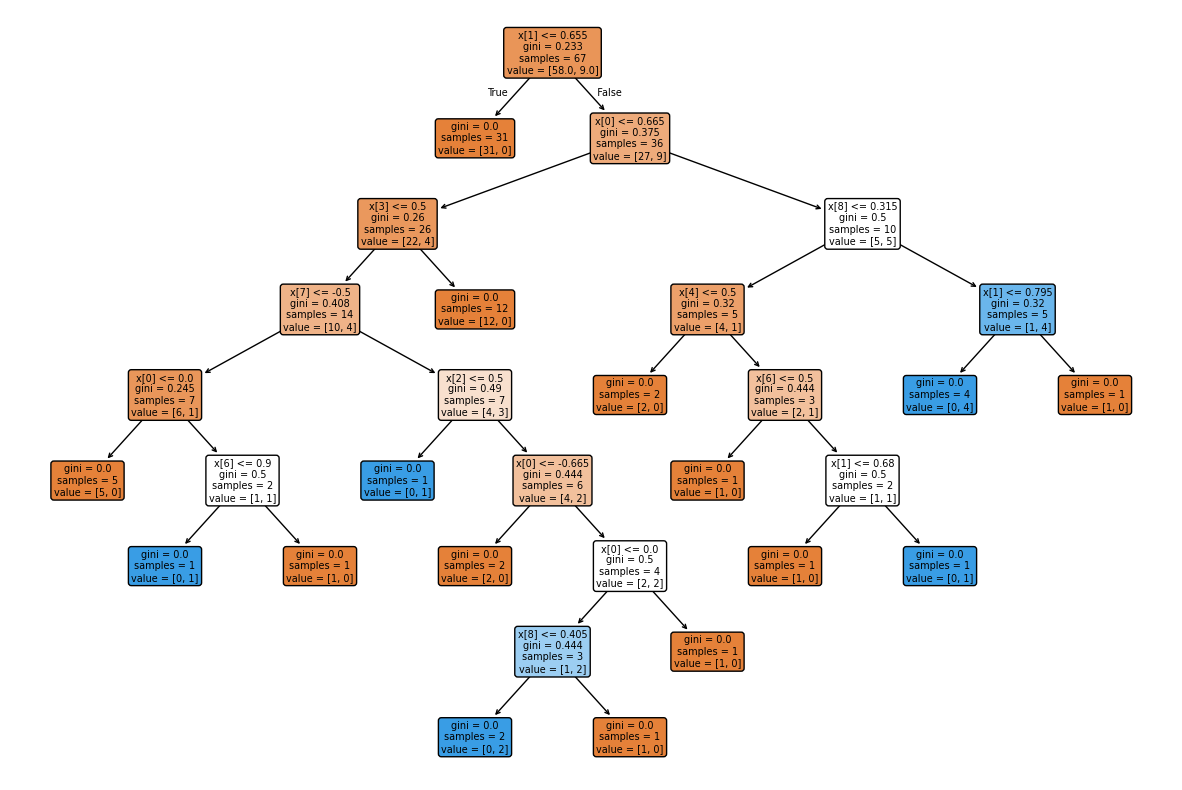

In [21]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(Model_1,filled=True,rounded=True,fontsize=7)
plt.show()

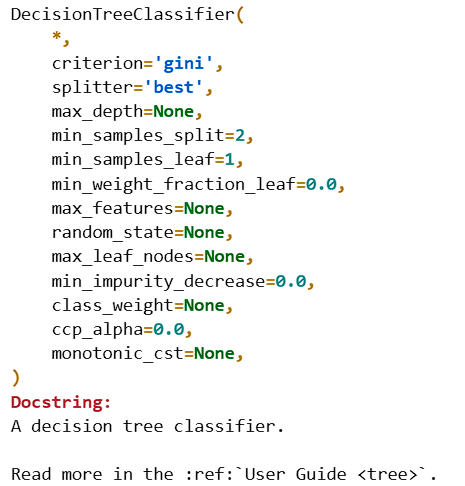

### Task
1. Specified depth 
2. Display accuracy of new Model
3. Display the desion tree Model(above visualization)

In [22]:
Tree2 = DecisionTreeClassifier(max_depth=4,random_state=42)
Tree2.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [23]:
Tree2.score(X_train,y_train)

0.9253731343283582

In [24]:
Tree2.score(X_test,y_test)

0.9393939393939394

### Display the decision tree model

In [25]:
!pip install graphviz

Defaulting to user installation because normal site-packages is not writeable


In [26]:
from sklearn.tree import export_graphviz
import graphviz 

In [27]:
# export_graphviz(
#                 Tree2,out_file="fertilitynew.dot" ,
#                 class_names=["N","O"],
#                 feature_names=X_train.columns,
#                 impurity=False,filled=True
#                )

In [28]:
# with open(r"C:\Users\Lenovo\Data Science\Classroom\Module_2\Classification\fertilitynew.dot") as file:
#     dot_graph = file.read()

# graphviz.Source(dot_graph)

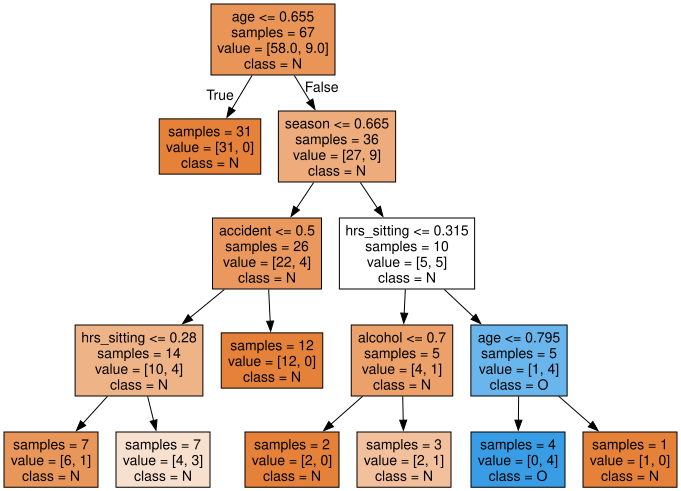

In [29]:
from sklearn.tree import export_graphviz
import graphviz   # <-- Import graphviz

# Export the tree to a .dot file
export_graphviz(
    Tree2,
    out_file="fertilitynew.dot",
    class_names=["N", "O"],
    feature_names=X_train.columns,
    impurity=False,
    filled=True
)

# Read the .dot file and render
with open("fertilitynew.dot") as file:
    dot_graph = file.read()

graphviz.Source(dot_graph)

In [30]:
Tree2.feature_importances_

array([0.19007121, 0.4043631 , 0.        , 0.11585293, 0.        ,
       0.        , 0.02928505, 0.        , 0.26042772])

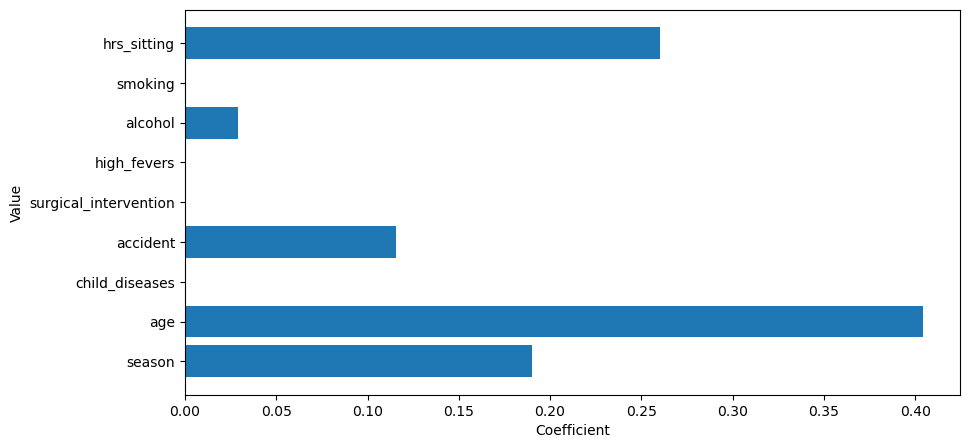

In [34]:
plt.figure(figsize=(10,5))
plt.yticks(range(0,9),X_train.columns)
plt.barh(range(0,9),Tree2.feature_importances_,align='center')
plt.xlabel('Coefficient')
plt.ylabel('Value')
plt.show()

### Drop unimportant columns and bulid new model